# Loan Risk Assessment Supervised Machine Learning Predictive Model

## Problem Statement:Create a predictive model that can predict Risk Score.

In [1]:
import pandas as pd
import numpy as np
Loan_Risk_Data=pd.read_excel("C:/Users/abrau/ML Projects/Python IVY Feb-2024-20260611T164017Z-3-001/Python IVY Feb-2024/My ML Projects/Regression projects/Loan/Loan.xlsx")
print(Loan_Risk_Data.shape)
Loan_Risk_Data.drop_duplicates()
print(Loan_Risk_Data.shape)

(20000, 36)
(20000, 36)


In [2]:
import datetime

In [3]:
Loan_Risk_Data.drop('ApplicationDate',axis=1,inplace=True)

In [4]:
Loan_Risk_Data.head(10)

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,39948,617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,39709,628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,40724,570,Employed,Bachelor,26,17627,36,Married,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,69084,545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,103264,594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0
5,37,178310,626,Self-Employed,Master,16,15433,72,Married,0,...,14859.166667,0.756079,5,27071,0.217433,0.217601,385.577074,0.075211,1,44.0
6,58,51250,564,Employed,High School,39,12741,48,Married,0,...,4270.833333,0.884275,5,21730,0.225741,0.205271,391.300352,0.170529,0,50.0
7,49,97345,516,Employed,High School,23,19634,12,Divorced,5,...,8112.083333,0.933492,5,38621,0.226634,0.209113,1827.360055,0.260767,1,42.4
8,34,116841,603,Employed,Bachelor,12,55353,60,Divorced,5,...,9736.750000,0.728397,3,7711,0.258853,0.291539,1762.199026,0.246509,0,61.0
9,46,40615,612,Employed,Associate,19,25443,12,Married,4,...,3384.583333,0.615323,3,116812,0.184443,0.197271,2353.577424,0.903384,0,53.0


## Target Variable is Risk Score.

<Axes: >

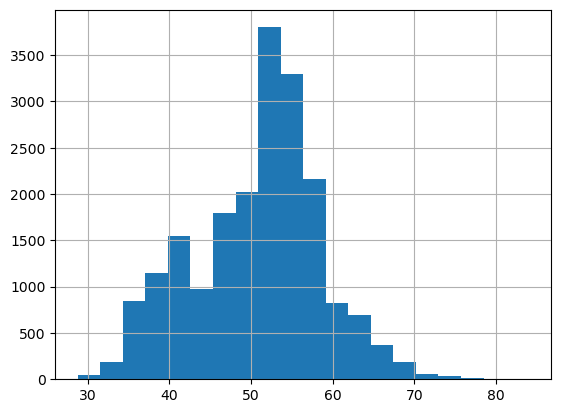

In [5]:
Loan_Risk_Data['RiskScore'].hist(bins=20)

In [6]:
Loan_Risk_Data.nunique()

Age                              63
AnnualIncome                  17516
CreditScore                     322
EmploymentStatus                  3
EducationLevel                    5
Experience                       62
LoanAmount                    15578
LoanDuration                     10
MaritalStatus                     4
NumberOfDependents                6
HomeOwnershipStatus               4
MonthlyDebtPayments            1299
CreditCardUtilizationRate     20000
NumberOfOpenCreditLines          14
NumberOfCreditInquiries           8
DebtToIncomeRatio             20000
BankruptcyHistory                 2
LoanPurpose                       5
PreviousLoanDefaults              2
PaymentHistory                   38
LengthOfCreditHistory            29
SavingsAccountBalance          9199
CheckingAccountBalance         5151
TotalAssets                   18814
TotalLiabilities              17163
MonthlyIncome                 17489
UtilityBillsPaymentHistory    20000
JobTenure                   

CategoricalColumns:['LoanDuration', 'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus,'NumberOfOpenCreditLines', 'NumberOfCreditInquiries',
'BankruptcyHistory', 'LoanPurpose', 'PreviousLoanDefaults', 'LoanApproved','EmploymentStatus', 'EducationLevel',]
ContinousColumns:['JobTenure','Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount','MonthlyDebtPayments', 'CreditCardUtilizationRate','DebtToIncomeRatio',
                 'PaymentHistory','LengthOfCreditHistory','SavingsAccountBalance',
       'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities',
       'MonthlyIncome','NetWorth',
       'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment',
       'TotalDebtToIncomeRatio']
QualitativeColumns:['ApplicationDate']

In [7]:
Loan_Risk_Data.columns

Index(['Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus',
       'EducationLevel', 'Experience', 'LoanAmount', 'LoanDuration',
       'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus',
       'MonthlyDebtPayments', 'CreditCardUtilizationRate',
       'NumberOfOpenCreditLines', 'NumberOfCreditInquiries',
       'DebtToIncomeRatio', 'BankruptcyHistory', 'LoanPurpose',
       'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
       'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
       'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
       'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate',
       'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved',
       'RiskScore'],
      dtype='object')

In [8]:
Loan_Risk_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  int64  
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              20000 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               20000 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [9]:
Loan_Risk_Data.describe()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,59161.473550,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,40350.845168,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,15000.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,31679.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,48566.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,74391.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,485341.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


## Uni Variate Analysis by Histogram

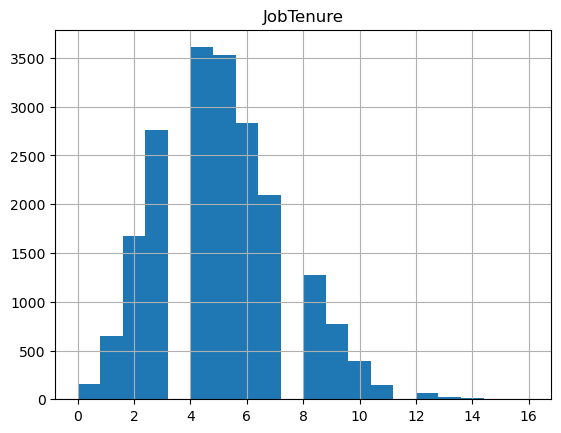

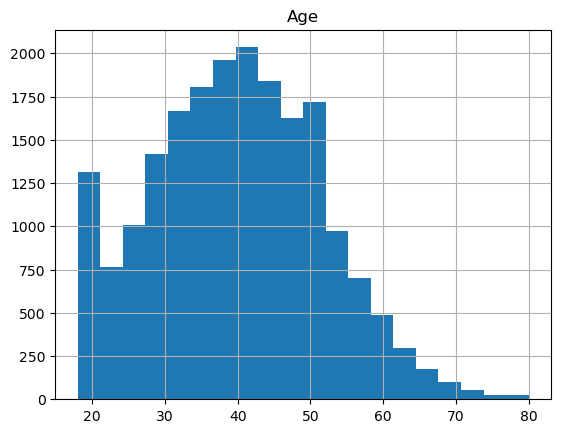

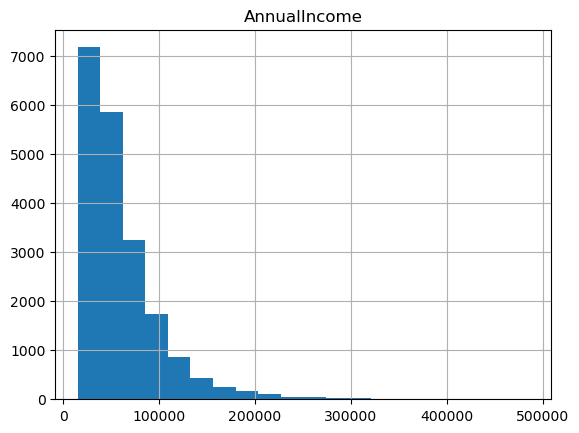

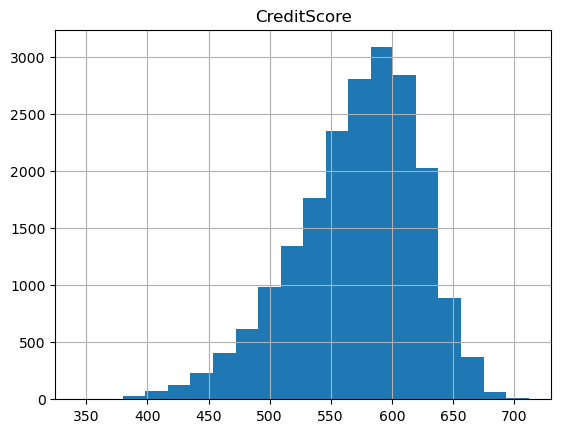

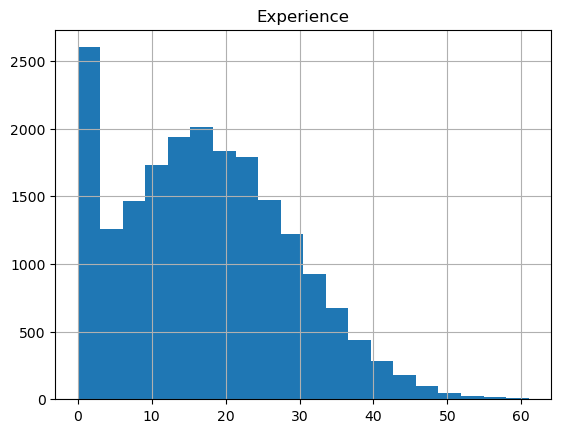

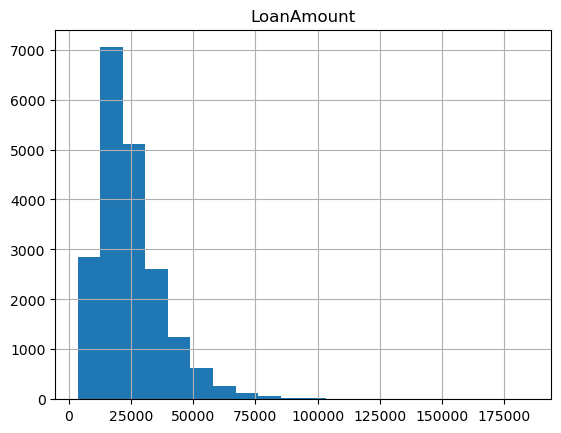

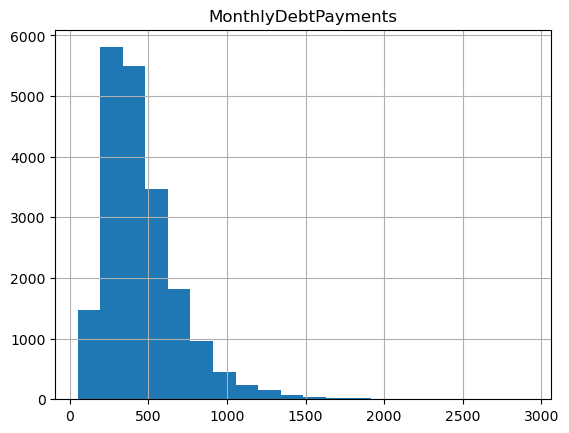

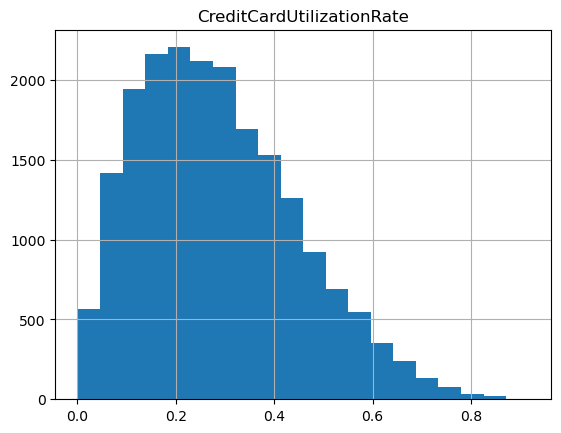

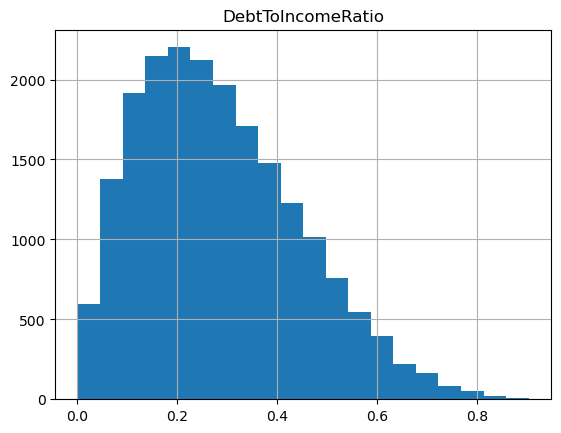

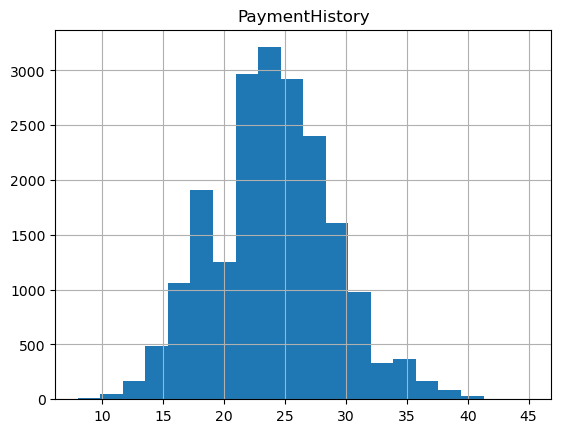

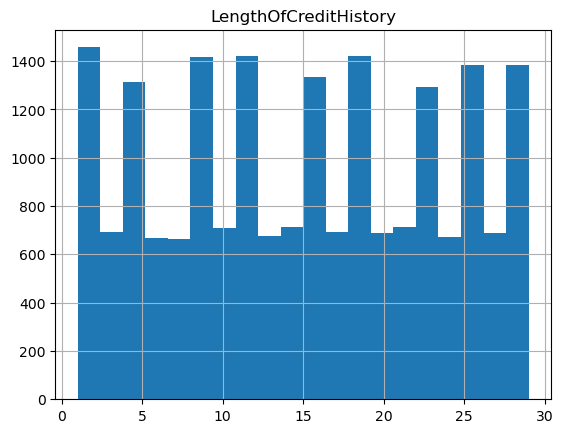

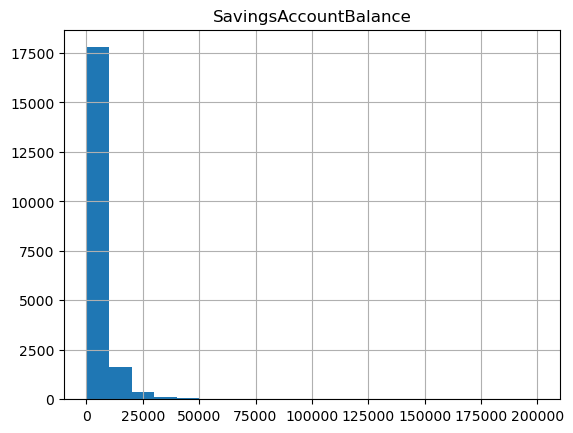

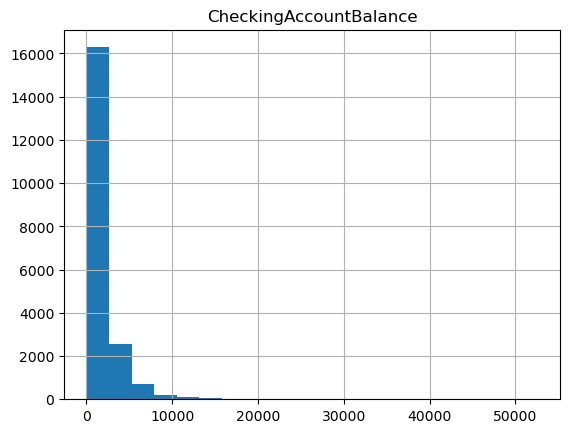

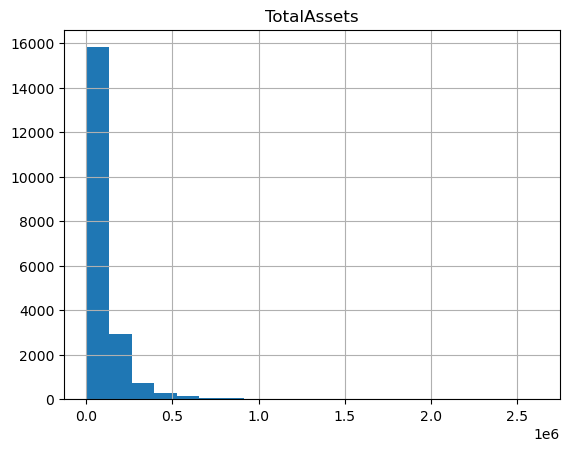

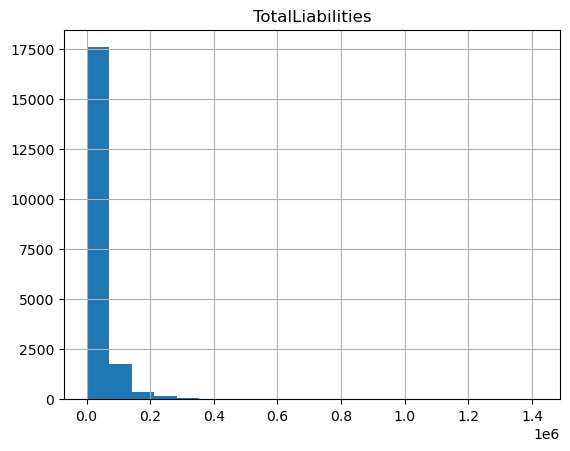

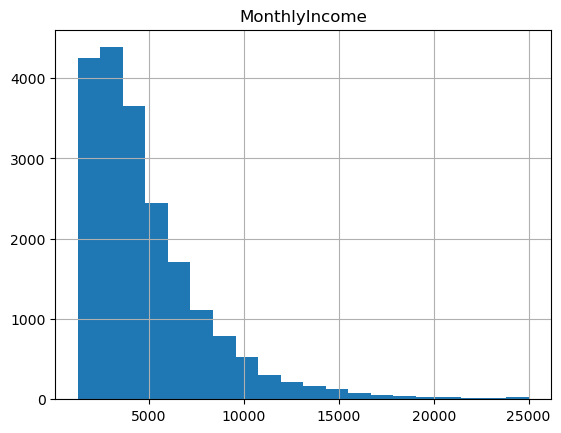

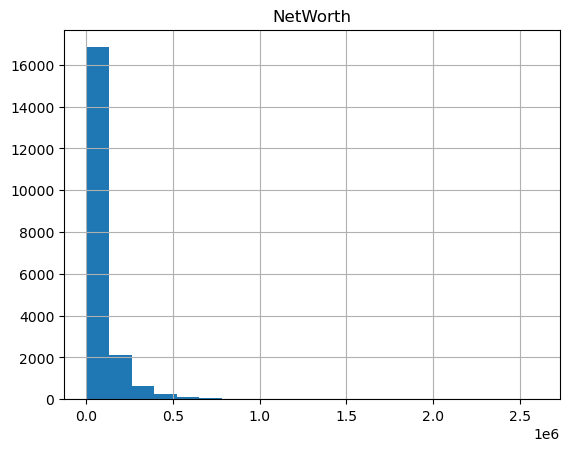

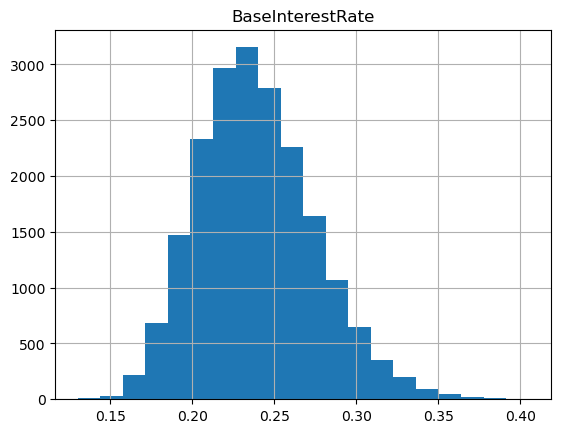

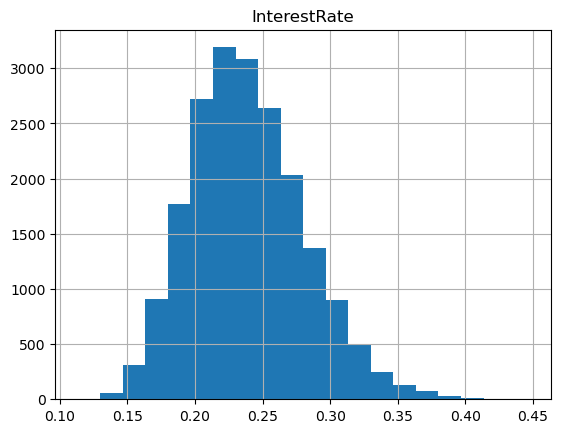

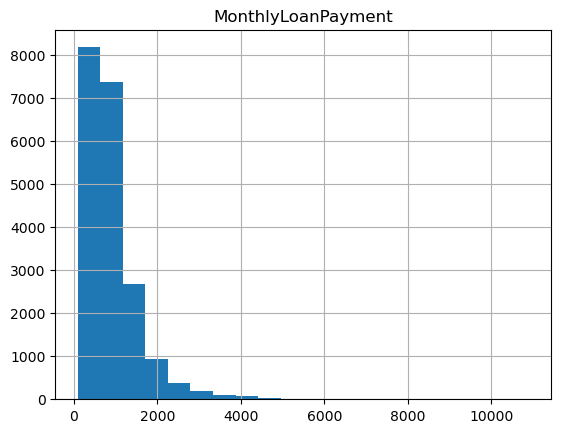

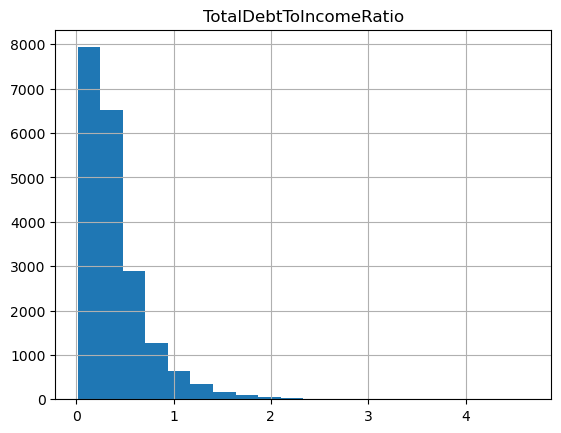

In [10]:
ContinousColumns=['JobTenure','Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount','MonthlyDebtPayments',
                   'CreditCardUtilizationRate','DebtToIncomeRatio', 'PaymentHistory','LengthOfCreditHistory','SavingsAccountBalance', 
                   'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome','NetWorth', 'BaseInterestRate',
                   'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio'] 

import matplotlib.pyplot as plt
for cols in ContinousColumns:
    Loan_Risk_Data[cols].hist(bins=20)
    plt.title(cols)
    plt.show() 

## No Need for outlier treatment

## Uni Variate Analysis by Bar Charts

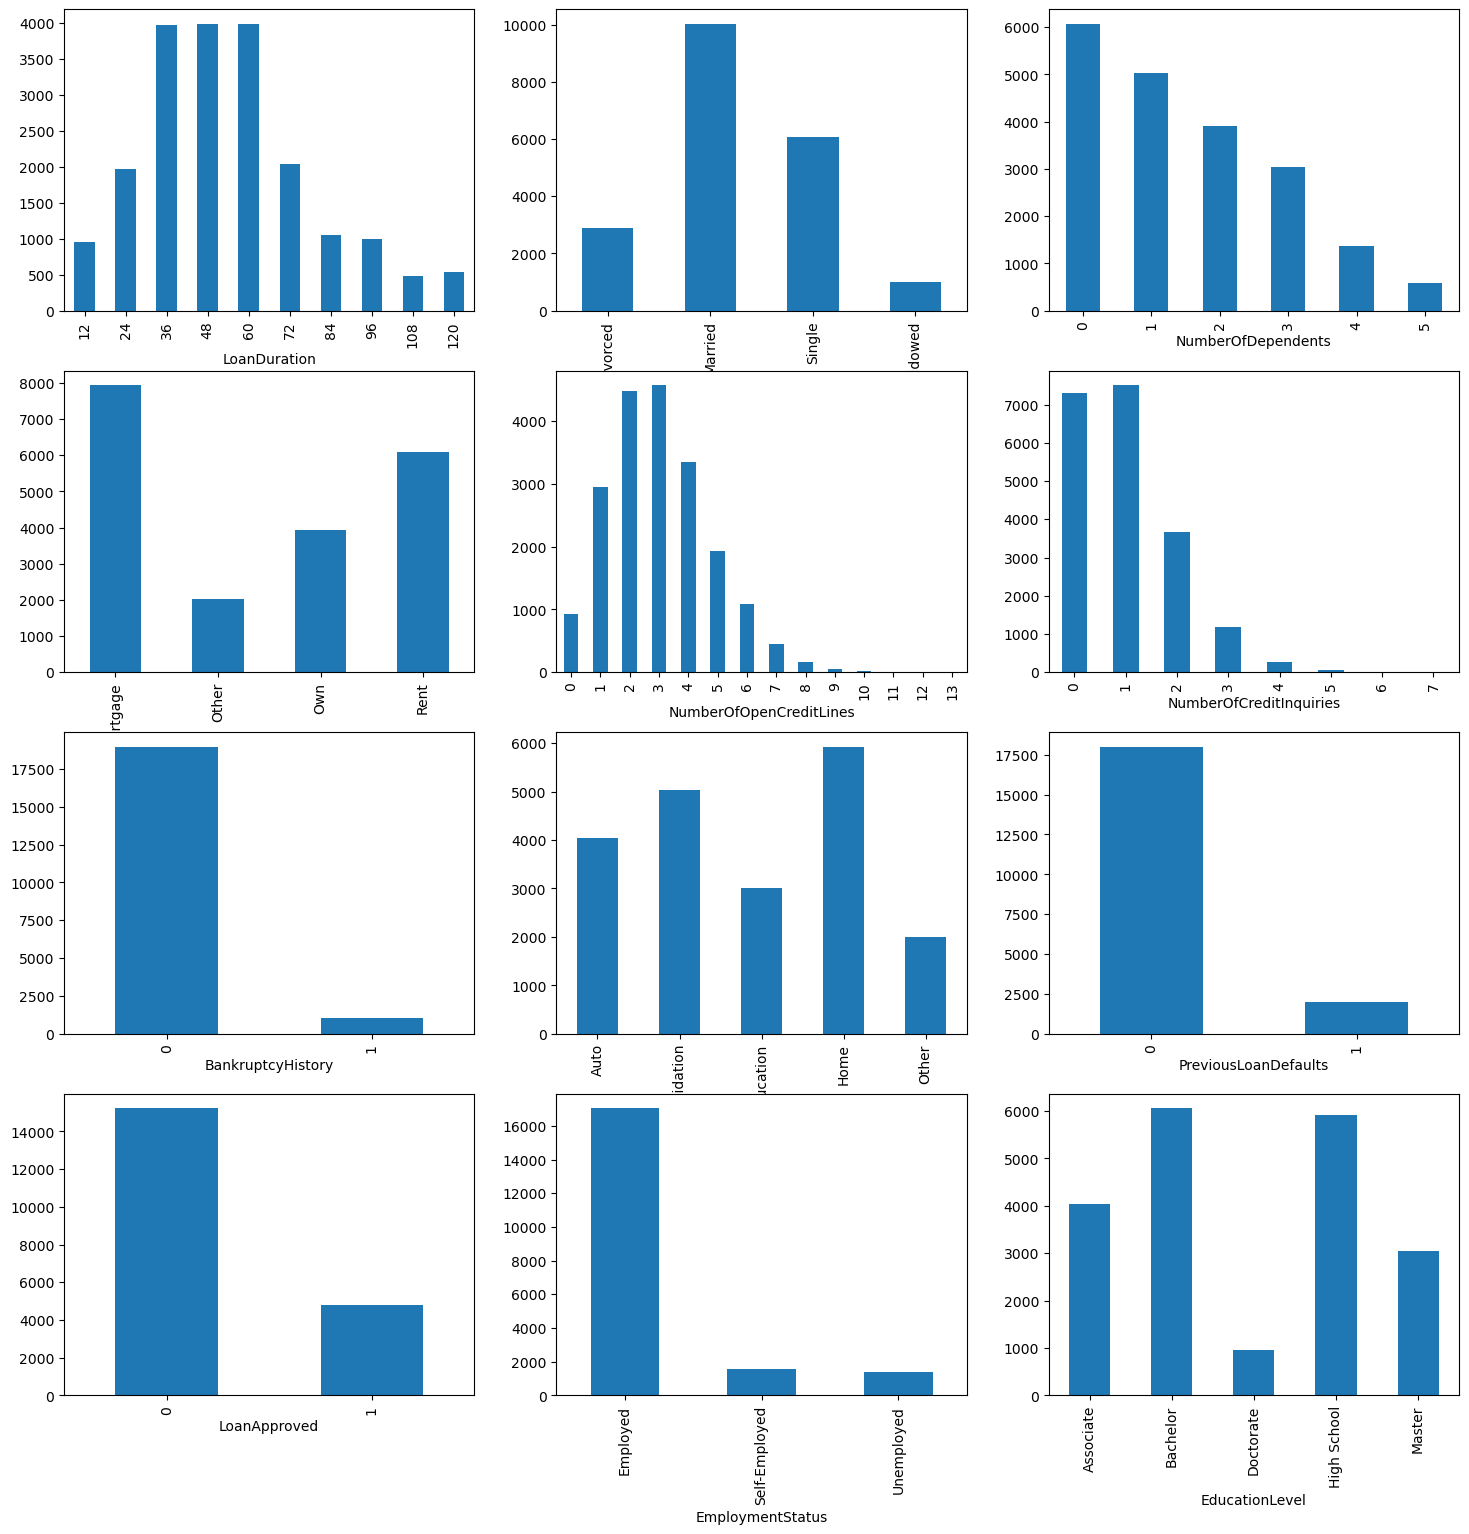

In [11]:
CategoricalColumns=['LoanDuration', 'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus','NumberOfOpenCreditLines', 
'NumberOfCreditInquiries', 'BankruptcyHistory', 'LoanPurpose', 'PreviousLoanDefaults', 'LoanApproved','EmploymentStatus', 'EducationLevel']
import matplotlib.pyplot as plt
fig, subplots=plt.subplots(4,3,figsize=(18,18))
subplots=subplots.flatten()
for cols,no_of_cols in zip(CategoricalColumns,range(len(CategoricalColumns))):
    Loan_Risk_Data.groupby(cols).size().plot(kind='bar',ax=subplots[no_of_cols])

In [12]:
Can be removed columns:

SyntaxError: invalid syntax (3052840643.py, line 1)

## Imbalance treatment

In [ ]:
(Loan_Risk_Data['NumberOfOpenCreditLines']).sort_values(ascending=False)

In [ ]:
Loan_Risk_Data.loc[Loan_Risk_Data['MaritalStatus']=='Widowed','MaritalStatus']='Divorced'

In [ ]:
Loan_Risk_Data.loc[Loan_Risk_Data['MaritalStatus']=='Divorced','MaritalStatus']='Others'

In [ ]:
Loan_Risk_Data.loc[Loan_Risk_Data['NumberOfOpenCreditLines'].isin([9,10,11,12]),['NumberOfOpenCreditLines']]=8

In [ ]:
Loan_Risk_Data.loc[Loan_Risk_Data['NumberOfOpenCreditLines'].isin([13]),['NumberOfOpenCreditLines']]=8

In [ ]:
Loan_Risk_Data['NumberOfOpenCreditLines']=Loan_Risk_Data['NumberOfOpenCreditLines'].astype(str)

In [ ]:
Loan_Risk_Data.loc[Loan_Risk_Data['NumberOfOpenCreditLines']=='8',['NumberOfOpenCreditLines']]='Others'

In [ ]:
Loan_Risk_Data['NumberOfCreditInquiries']=Loan_Risk_Data['NumberOfCreditInquiries'].astype(str)

In [ ]:
Loan_Risk_Data.loc[Loan_Risk_Data['NumberOfCreditInquiries'].isin(['5','6','7']),['NumberOfCreditInquiries']]='Others'

In [ ]:
Loan_Risk_Data.loc[Loan_Risk_Data['NumberOfCreditInquiries'].isin(['4']),['NumberOfCreditInquiries']]='Others'

In [ ]:
Loan_Risk_Data.loc[Loan_Risk_Data['EmploymentStatus'].isin(['4']),['EmploymentStatus']]='Others'

In [ ]:
Loan_Risk_Data['EmploymentStatus'].unique()

In [ ]:
Loan_Risk_Data.loc[Loan_Risk_Data['EmploymentStatus'].isin(['Self-Employed','Unemployed']),'EmploymentStatus']='Others'

In [ ]:
Loan_Risk_Data.groupby('EmploymentStatus').size().plot(kind='bar')

In [ ]:
Loan_Risk_Data.isnull().sum()

### Missing value treatment is not needed.

## Continuous Vs Continuous -- Scatter Charts

In [ ]:
ContinousColumns=['JobTenure','Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount','MonthlyDebtPayments',
                   'CreditCardUtilizationRate','DebtToIncomeRatio', 'PaymentHistory','LengthOfCreditHistory','SavingsAccountBalance', 
                   'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome','NetWorth', 'BaseInterestRate',
                   'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio'] 
for cols in ContinousColumns:
    Loan_Risk_Data.plot.scatter(x=cols,y='RiskScore')

## Statistical Feature Selection (Continuous Vs Continuous) using Correlation value

In [ ]:
ContinousColumns=['JobTenure','Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount','MonthlyDebtPayments',
                   'CreditCardUtilizationRate','DebtToIncomeRatio', 'PaymentHistory','LengthOfCreditHistory','SavingsAccountBalance', 
                   'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome','NetWorth', 'BaseInterestRate',
                   'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio','RiskScore'] 
corrdata=Loan_Risk_Data[ContinousColumns].corr()
corrdata['RiskScore']



In [ ]:
Loan_Risk_Data.columns

### Columns which higher than other columns with RiskScore are AnnualIncome,MonthlyIncome,DebtToIncomeRatio,NetWorth

## Categorical Vs Continuous -- Box Plots

In [ ]:
CategoricalColumns=['LoanDuration', 'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus','NumberOfOpenCreditLines', 
'NumberOfCreditInquiries', 'BankruptcyHistory', 'LoanPurpose', 'PreviousLoanDefaults', 'LoanApproved','EmploymentStatus', 'EducationLevel'] 
import matplotlib.pyplot as plt
fig, subplots=plt.subplots(4,3,figsize=(18,18))
subplots=subplots.flatten()
for cols, no_of_cols in zip(CategoricalColumns,range(len(CategoricalColumns))):
    Loan_Risk_Data.boxplot(column='RiskScore',by=cols,vert=True,ax=subplots[no_of_cols])


## Statistical Feature Selection (Categorical Vs Continuous) using ANOVA test

In [ ]:
CategoricalColumns=['LoanDuration', 'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus','NumberOfOpenCreditLines', 
'NumberOfCreditInquiries', 'BankruptcyHistory', 'LoanPurpose', 'PreviousLoanDefaults', 'LoanApproved','EmploymentStatus', 'EducationLevel'] 
def functionAnova(data, targetVariable,CategoricalColumns):
    from scipy.stats import f_oneway
    SelectedPredictors=[]
    for cols in CategoricalColumns:
        CategoricalGroupLists=data.groupby(cols)[targetVariable].apply(list)
        AnovaResults=f_oneway(*CategoricalGroupLists)
        if AnovaResults[1]<0.05:
            SelectedPredictors.append(cols)
            print('Risk Score is correlated with ',cols, 'and p value is ',AnovaResults[1])
        else:
            print('Risk Score is correlated with ',cols, 'and p value is ',AnovaResults[1])
    return SelectedPredictors
functionAnova(Loan_Risk_Data, 'RiskScore',CategoricalColumns)

These categorical columns are correlated with target Variable:['LoanDuration',
 'BankruptcyHistory',
 'LoanPurpose',
 'PreviousLoanDefaults',
 'LoanApproved',
 'EmploymentStatus',
 'EducationLevel']

In [ ]:
Loan_Risk_Data.columns

In [14]:
SelectedColumns=['Age', 'AnnualIncome', 'CreditScore',
       'EmploymentStatus', 'EducationLevel', 'Experience', 'LoanAmount',
       'LoanDuration', 'MaritalStatus', 'NumberOfDependents',
       'HomeOwnershipStatus', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
       'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory', 
       'LengthOfCreditHistory', 'SavingsAccountBalance',
       'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities',
       'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth',
       'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment',
       'TotalDebtToIncomeRatio', 'LoanApproved']

DataForMLLoan_Risk_Data=Loan_Risk_Data[SelectedColumns]
DataForMLLoan_Risk_Data.to_pickle('DataForMLLoan_Risk_Data.pkl')
DataForMLLoan_Risk_Data=pd.read_pickle('DataForMLLoan_Risk_Data.pkl')
DataForMLLoan_Risk_Data_Numeric=pd.get_dummies(DataForMLLoan_Risk_Data)

DataForMLLoan_Risk_Data_Numeric.replace({True:1,False:0},inplace=True)
DataForMLLoan_Risk_Data_Numeric.head()

C:\Users\abrau\AppData\Local\Temp\ipykernel_111980\631914649.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  DataForMLLoan_Risk_Data_Numeric.replace({True:1,False:0},inplace=True)


,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MaritalStatus_Widowed,HomeOwnershipStatus_Mortgage,HomeOwnershipStatus_Other,HomeOwnershipStatus_Own,HomeOwnershipStatus_Rent,LoanPurpose_Auto,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,45,39948,617,22,13152,48,2,183,0.354418,1,...,0,0,0,1,0,0,0,0,1,0
1,38,39709,628,15,26045,48,1,496,0.087827,5,...,0,1,0,0,0,0,1,0,0,0
2,47,40724,570,26,17627,36,2,902,0.137414,2,...,0,0,0,0,1,0,0,1,0,0
3,58,69084,545,34,37898,96,1,755,0.267587,2,...,0,1,0,0,0,0,0,0,1,0
4,37,103264,594,17,9184,36,1,274,0.320535,0,...,0,1,0,0,0,0,1,0,0,0


In [15]:
for cols in DataForMLLoan_Risk_Data_Numeric.select_dtypes(include='object').columns:
    DataForMLLoan_Risk_Data_Numeric[cols]=pd.to_numeric(
        DataForMLLoan_Risk_Data_Numeric[cols],
        errors='coerce'
    )
    

In [ ]:
DataForMLLoan_Risk_Data_Numeric.shape

In [ ]:
DataForMLLoan_Risk_Data_Numeric.info()

In [ ]:
pd.set_option('Display.max_columns',False)

In [16]:
DataForMLLoan_Risk_Data_Numeric['RiskScore']=Loan_Risk_Data['RiskScore']
DataForMLLoan_Risk_Data_Numeric.head()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,HomeOwnershipStatus_Mortgage,HomeOwnershipStatus_Other,HomeOwnershipStatus_Own,HomeOwnershipStatus_Rent,LoanPurpose_Auto,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,RiskScore
0,45,39948,617,22,13152,48,2,183,0.354418,1,...,0,0,1,0,0,0,0,1,0,49.0
1,38,39709,628,15,26045,48,1,496,0.087827,5,...,1,0,0,0,0,1,0,0,0,52.0
2,47,40724,570,26,17627,36,2,902,0.137414,2,...,0,0,0,1,0,0,1,0,0,52.0
3,58,69084,545,34,37898,96,1,755,0.267587,2,...,1,0,0,0,0,0,0,1,0,54.0
4,37,103264,594,17,9184,36,1,274,0.320535,0,...,1,0,0,0,0,1,0,0,0,36.0


In [38]:
pd.set_option('display.max_columns',None)

In [58]:
DataForMLLoan_Risk_Data_Numeric.head()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,EmploymentStatus_Employed,EmploymentStatus_Self-Employed,EmploymentStatus_Unemployed,EducationLevel_Associate,EducationLevel_Bachelor,EducationLevel_Doctorate,EducationLevel_High School,EducationLevel_Master,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,HomeOwnershipStatus_Mortgage,HomeOwnershipStatus_Other,HomeOwnershipStatus_Own,HomeOwnershipStatus_Rent,LoanPurpose_Auto,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,RiskScore
0,45,39948,617,22,13152,48,2,183,0.354418,1,2,0.358336,0,0,29,9,7632,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,49.0
1,38,39709,628,15,26045,48,1,496,0.087827,5,3,0.330274,0,0,21,9,4627,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,52.0
2,47,40724,570,26,17627,36,2,902,0.137414,2,0,0.244729,0,0,20,22,886,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,52.0
3,58,69084,545,34,37898,96,1,755,0.267587,2,1,0.436244,0,0,27,10,1675,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,1,0,54.0
4,37,103264,594,17,9184,36,1,274,0.320535,0,0,0.078884,0,0,26,27,1555,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,36.0


In [59]:
DataForMLLoan_Risk_Data_Numeric.shape

(20000, 51)

In [57]:

predictors=['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount',
       'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
       'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
       'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
       'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
       'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate',
       'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved',
       'EmploymentStatus_Employed', 'EmploymentStatus_Self-Employed',
       'EmploymentStatus_Unemployed', 'EducationLevel_Associate',
       'EducationLevel_Bachelor', 'EducationLevel_Doctorate',
       'EducationLevel_High School', 'EducationLevel_Master',
       'MaritalStatus_Divorced', 'MaritalStatus_Married',
       'MaritalStatus_Single', 'MaritalStatus_Widowed',
       'HomeOwnershipStatus_Mortgage', 'HomeOwnershipStatus_Other',
       'HomeOwnershipStatus_Own', 'HomeOwnershipStatus_Rent',
       'LoanPurpose_Auto', 'LoanPurpose_Debt Consolidation',
       'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other']



targetVariable='RiskScore'
X=DataForMLLoan_Risk_Data_Numeric[predictors].values
y=DataForMLLoan_Risk_Data_Numeric[targetVariable].values
#from sklearn.preprocessing import PolynomialFeatures
#poly=PolynomialFeatures(degree=2,include_bias=False)
#X=poly.fit_transform(X)
#predictors=poly.get_feature_names_out()

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=45,test_size=0.2)



print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(16000, 50)
(16000,)
(4000, 50)
(4000,)


In [ ]:
DataForMLLoan_Risk_Data_Numeric.head()

## Linear Regression

In [18]:
from sklearn.linear_model import LinearRegression
RegModel=LinearRegression()
LREG=RegModel.fit(X_train,y_train)
from sklearn import metrics
print('R2 Value:',np.round((metrics.r2_score(y_train,LREG.predict(X_train))*100),2),'%')
prediction=LREG.predict(X_test)
TestingDataResults=pd.DataFrame(X_test,columns=predictors)
TestingDataResults[targetVariable]=y_test
TestingDataResults['Predicted',targetVariable]=prediction
TestingDataResults.head()
TestingDataResults['APE']=100*(abs(TestingDataResults['Predicted',targetVariable]-TestingDataResults[targetVariable])/TestingDataResults[targetVariable])
MAPE=np.mean(TestingDataResults['APE'])
MedianAPE=MAPE=np.median(TestingDataResults['APE'])
MeanAccuracy=100-MAPE
MedianAccuracy=100-MedianAPE
print(MeanAccuracy)
print(MedianAccuracy)
def AccuracyScore(orig,pred):
    MAPE=np.mean(abs(orig-pred)/orig)
    return 100-MAPE
from sklearn.metrics import make_scorer
custom_scoring=make_scorer(AccuracyScore,greater_is_better=True) 
from sklearn.model_selection import cross_val_score
AccuracyScore=cross_val_score(LREG,X,y,cv=5,scoring=custom_scoring)
print(AccuracyScore)
print('Final Accuracy of the Model:',np.round(np.mean(AccuracyScore),2),'%')


R2 Value: 93.96 %
97.53287951476496
97.53287951476496
[99.96982487 99.97008683 99.96981425 99.9696004  99.97005249]
Final Accuracy of the Model: 99.97 %


## Decision Tree

R2 Value: 94.45 %
97.33231668572881
97.33231668572881
[99.96898737 99.96885391 99.9687111  99.96795986 99.96838741]
Final Accuracy of the Model: 99.97 %


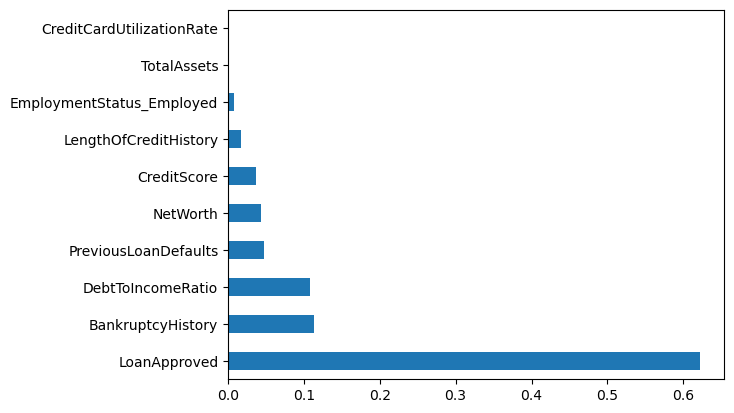

In [20]:
from sklearn.tree import DecisionTreeRegressor
RegModel=DecisionTreeRegressor(max_depth=8,criterion='squared_error')
DT=RegModel.fit(X_train,y_train)
from sklearn import metrics
print('R2 Value:',np.round((metrics.r2_score(y_train,DT.predict(X_train))*100),2),'%')
Feature_Importances=pd.Series(DT.feature_importances_,index=predictors)
Feature_Importances.nlargest(10).plot(kind='barh')
prediction=DT.predict(X_test)
TestingDataResults=pd.DataFrame(X_test,columns=predictors)
TestingDataResults[targetVariable]=y_test
TestingDataResults['Predicted',targetVariable]=prediction
TestingDataResults.head()
TestingDataResults['APE']=100*(abs(TestingDataResults['Predicted',targetVariable]-TestingDataResults[targetVariable])/TestingDataResults[targetVariable])
MAPE=np.mean(TestingDataResults['APE'])
MedianAPE=MAPE=np.median(TestingDataResults['APE'])
MeanAccuracy=100-MAPE
MedianAccuracy=100-MedianAPE
print(MeanAccuracy)
print(MedianAccuracy)
def AccuracyScore(orig,pred):
    MAPE=np.mean(abs(orig-pred)/orig)
    return 100-MAPE
from sklearn.metrics import make_scorer
custom_scoring=make_scorer(AccuracyScore,greater_is_better=True) 
from sklearn.model_selection import cross_val_score
AccuracyScore=cross_val_score(DT,X,y,cv=5,scoring=custom_scoring)
print(AccuracyScore)
print('Final Accuracy of the Model:',np.round(np.mean(AccuracyScore),2),'%')


## Random Forest Regressor

In [ ]:
from datetime import datetime
start_time=datetime.now()

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
RegModel = RandomForestRegressor(n_estimators=100,criterion='squared_error')
 
#Printing all the parameters of Random Forest
print(RegModel)
 
#Creating the model on Training Data
RF=RegModel.fit(X_train,y_train)
prediction=RF.predict(X_test) 
 
#Measuring Goodness of fit in Training data
from sklearn import metrics
print('R2 Value:',metrics.r2_score(y_train, RF.predict(X_train)))
mse = mean_squared_error(y_test, prediction)
print('mse',mse)
#Measuring accuracy on Testing Data
print('Accuracy',100- (np.mean(np.abs((y_test - prediction) / y_test)) * 100))
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(RF.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults[targetVariable]=y_test
TestingDataResults[('Predicted'+targetVariable)]=prediction
TestingDataResults.head()

end_time=datetime.now()
et=end_time-start_time
print(et)

## XGBRegressor

XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.008, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)
R2 Value: 0.9464038749352978
Final Accuracy of the Model: 97.06 %


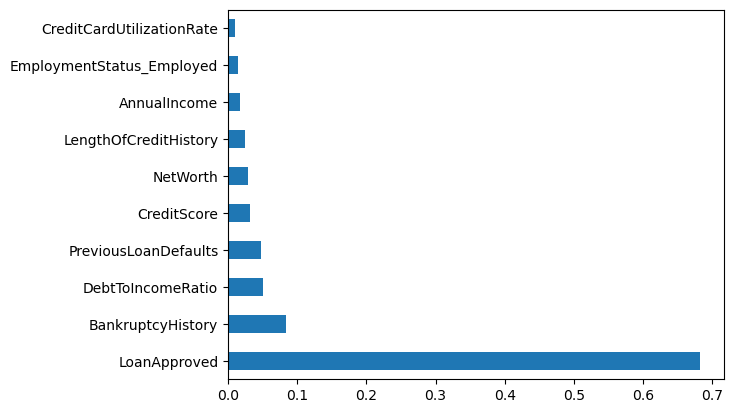

In [35]:
from xgboost import XGBRegressor
RegModel=XGBRegressor(max_depth=3, learning_rate=0.008, n_estimators=500, objective='reg:squarederror', booster='gbtree')
 
#Printing all the parameters of XGBoost
print(RegModel)
 
#Creating the model on Training Data
XGB=RegModel.fit(X_train,y_train)
prediction=XGB.predict(X_test)
 
#Measuring Goodness of fit in Training data
from sklearn import metrics  
print('R2 Value:',metrics.r2_score(y_train, XGB.predict(X_train)))
 
#Measuring accuracy on Testing Data
#print('Accuracy',100- (np.mean(np.abs((y_test - prediction) / y_test)) * 100))
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(XGB.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults[targetVariable]=y_test
TestingDataResults[('Predicted'+targetVariable)]=prediction
TestingDataResults.head()
print('Final Accuracy of the Model:',round(100- (np.mean(np.abs((y_test - prediction) / y_test)) * 100),2),'%')

## AdaBoost Regressor

AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=5),
                  learning_rate=0.1, n_estimators=100)
R2 Value: 0.9292791101441992
Accuracy 96.57214507945119


,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,HomeOwnershipStatus_Other,HomeOwnershipStatus_Own,HomeOwnershipStatus_Rent,LoanPurpose_Auto,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,RiskScore,PredictedRiskScore
0,40.0,69714.0,607.0,21.0,16565.0,36.0,1.0,144.0,0.077587,3.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,36.8,38.072423
1,20.0,76617.0,567.0,0.0,22277.0,48.0,0.0,470.0,0.650463,2.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,52.0,51.555352
2,44.0,26125.0,508.0,20.0,18330.0,60.0,1.0,348.0,0.390425,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,58.0,56.200409
3,41.0,104175.0,458.0,18.0,48923.0,72.0,2.0,321.0,0.300447,2.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,55.0,54.017799
4,46.0,55300.0,459.0,26.0,35568.0,72.0,0.0,829.0,0.536702,6.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,51.0,51.881137


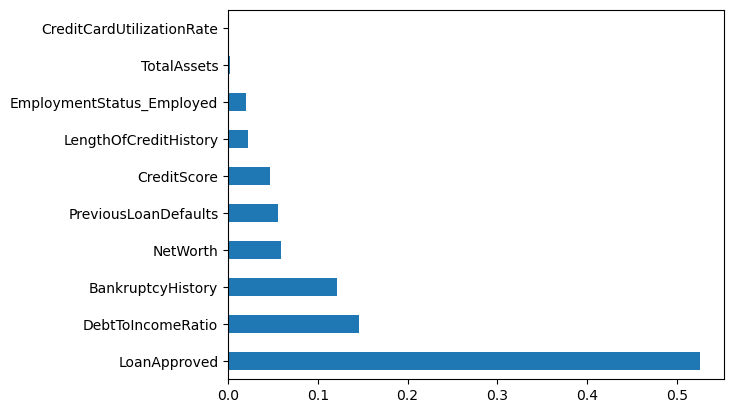

In [22]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
 
#Choosing Decision Tree with 1 level as the weak learner
DTR=DecisionTreeRegressor(max_depth=5)
RegModel = AdaBoostRegressor(n_estimators=100, estimator=DTR,learning_rate=0.1)
 
#Printing all the parameters of Adaboost
print(RegModel)
 
#Creating the model on Training Data
AB=RegModel.fit(X_train,y_train)
prediction=AB.predict(X_test)
 
#Measuring Goodness of fit in Training data
from sklearn import metrics
print('R2 Value:',metrics.r2_score(y_train, AB.predict(X_train)))
 
#Measuring accuracy on Testing Data
print('Accuracy',100- (np.mean(np.abs((y_test - prediction) / y_test)) * 100))
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(AB.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors) 
TestingDataResults[targetVariable]=y_test
TestingDataResults[('Predicted'+targetVariable)]=prediction
TestingDataResults.head()

## XGBoost is selected for deploying and Model Deployment on Sample Data

In [60]:
NewData=pd.DataFrame(data=[
[32,55000,720,8,12000,36,1,350,0.28,4,1,0.22,0,0,32,10,12000,3500,180000,40000,4583,0.95,5,140000,0.08,0.10,387,0.18,1,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0],
[45,82000,680,20,25000,60,2,700,0.45,6,2,0.35,0,0,28,15,22000,6000,260000,90000,6833,0.89,12,170000,0.11,0.13,569,0.31,1,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0],
[28,42000,640,4,8000,24,0,250,0.18,3,1,0.15,0,0,35,6,5000,1800,90000,15000,3500,0.97,2,75000,0.07,0.09,365,0.12,1,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0],
[54,110000,750,30,40000,84,3,1200,0.52,8,3,0.41,0,0,30,25,45000,12000,420000,130000,9167,0.93,20,290000,0.10,0.12,710,0.36,1,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0],
[39,67000,610,12,18000,48,2,620,0.39,5,2,0.29,0,1,24,11,9000,2800,150000,85000,5583,0.82,7,65000,0.13,0.16,507,0.38,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0],

[31,48000,705,7,15000,36,1,420,0.24,4,1,0.20,0,0,34,8,11000,2500,130000,30000,4000,0.96,4,100000,0.08,0.10,484,0.19,1,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0],
[50,96000,730,22,35000,72,2,980,0.47,7,2,0.34,0,0,31,18,35000,7000,380000,110000,8000,0.91,14,270000,0.09,0.11,683,0.29,1,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0],
[27,39000,590,3,7000,24,0,180,0.15,2,0,0.12,0,0,26,4,2500,1200,70000,12000,3250,0.88,1,58000,0.14,0.17,346,0.11,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,1],
[42,73000,675,16,22000,60,2,680,0.36,5,2,0.27,0,0,29,13,15000,4200,210000,60000,6083,0.90,9,150000,0.10,0.12,489,0.25,1,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0],
[36,61000,650,10,14000,48,1,450,0.29,4,1,0.21,0,0,33,9,8000,3000,160000,42000,5083,0.94,6,118000,0.09,0.11,358,0.18,1,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0],

[46,88000,710,18,30000,60,2,860,0.42,6,2,0.31,0,0,30,16,27000,5000,290000,95000,7333,0.92,11,195000,0.10,0.12,667,0.28,1,1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,1,0,0],
[29,44000,620,5,9000,24,0,240,0.19,3,1,0.16,0,0,28,5,4000,1500,85000,17000,3667,0.89,3,65000,0.12,0.14,432,0.15,1,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0],
[55,118000,760,32,45000,84,3,1350,0.55,9,3,0.43,0,0,31,26,52000,13000,500000,160000,9833,0.95,23,340000,0.09,0.11,775,0.34,1,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0],
[41,69000,645,15,19000,48,1,590,0.31,5,2,0.24,0,0,27,12,14000,3600,185000,54000,5750,0.87,8,131000,0.11,0.14,525,0.22,1,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0],
[34,58000,700,9,16000,36,1,390,0.22,4,1,0.18,0,0,36,8,12500,2900,145000,35000,4833,0.98,5,110000,0.08,0.10,516,0.17,1,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,1,0],

[48,91000,735,21,33000,72,2,940,0.44,7,2,0.33,0,0,30,18,32000,6500,340000,98000,7583,0.93,13,242000,0.09,0.11,643,0.27,1,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0],
[26,37000,600,2,6000,24,0,160,0.14,2,0,0.10,0,0,25,3,1800,800,60000,10000,3083,0.85,1,50000,0.14,0.17,291,0.09,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,1,0],
[43,76000,690,17,24000,60,2,720,0.37,6,2,0.28,0,0,29,14,17500,4500,235000,70000,6333,0.91,10,165000,0.10,0.12,533,0.24,1,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0],
[38,64000,660,11,17000,48,1,510,0.27,4,1,0.20,0,0,32,10,9800,2600,170000,45000,5333,0.94,7,125000,0.09,0.11,390,0.19,1,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0],
[52,102000,745,25,39000,84,3,1180,0.50,8,3,0.40,0,0,31,21,41000,9800,430000,145000,8500,0.96,18,285000,0.10,0.12,702,0.32,1,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0],

[33,56000,715,8,13000,36,1,340,0.23,4,1,0.17,0,0,35,7,11800,2400,140000,32000,4667,0.97,4,108000,0.08,0.10,419,0.16,1,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0],
[47,85000,700,19,28000,60,2,810,0.41,6,2,0.30,0,0,30,17,26000,5400,300000,88000,7083,0.92,12,212000,0.10,0.12,622,0.26,1,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0],
[30,46000,630,6,10000,24,0,270,0.20,3,1,0.14,0,0,27,5,4200,1300,92000,18000,3833,0.90,2,74000,0.12,0.15,471,0.13,1,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,0],
[56,120000,770,33,47000,96,4,1450,0.58,10,4,0.45,0,0,32,28,60000,15000,560000,180000,10000,0.98,25,380000,0.09,0.11,820,0.36,1,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0],
[40,72000,670,14,21000,48,2,640,0.33,5,2,0.25,0,0,29,12,16000,3700,205000,59000,6000,0.93,8,146000,0.10,0.12,478,0.21,1,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0],

[35,60000,690,9,15500,36,1,430,0.25,4,1,0.19,0,0,34,8,10000,2800,155000,37000,5000,0.95,5,118000,0.09,0.11,500,0.18,1,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0],
[49,93000,725,22,34000,72,2,970,0.46,7,2,0.35,0,0,30,19,34000,6900,360000,105000,7750,0.94,14,255000,0.09,0.11,661,0.29,1,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0],
[28,41000,610,4,8500,24,0,210,0.17,3,0,0.13,0,0,26,4,3100,1100,78000,13000,3417,0.88,2,65000,0.13,0.16,398,0.12,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,1],
[44,79000,695,18,26000,60,2,760,0.38,6,2,0.29,0,0,29,15,20000,4800,255000,76000,6583,0.91,11,179000,0.10,0.12,578,0.25,1,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0],
[53,108000,750,27,41000,84,3,1250,0.53,8,3,0.42,0,0,31,23,47000,11000,455000,150000,9000,0.97,19,305000,0.09,0.11,735,0.33,1,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0]
],columns=predictors)

In [61]:
newX=NewData.values

In [62]:
pred=XGB.predict(newX)

In [64]:
def GeneratePred(inpData):
    newX=inpData.values
    pred=XGB.predict(newX)
    inpData['Prediction']=pred
    return (inpData) 




In [65]:
GeneratePred(inpData=NewData)

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,EmploymentStatus_Employed,EmploymentStatus_Self-Employed,EmploymentStatus_Unemployed,EducationLevel_Associate,EducationLevel_Bachelor,EducationLevel_Doctorate,EducationLevel_High School,EducationLevel_Master,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,HomeOwnershipStatus_Mortgage,HomeOwnershipStatus_Other,HomeOwnershipStatus_Own,HomeOwnershipStatus_Rent,LoanPurpose_Auto,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,Prediction
0,32,55000,720,8,12000,36,1,350,0.28,4,1,0.22,0,0,32,10,12000,3500,180000,40000,4583,0.95,5,140000,0.08,0.10,387,0.18,1,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0.0,35.892006
1,45,82000,680,20,25000,60,2,700,0.45,6,2,0.35,0,0,28,15,22000,6000,260000,90000,6833,0.89,12,170000,0.11,0.13,569,0.31,1,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0.0,37.583385
2,28,42000,640,4,8000,24,0,250,0.18,3,1,0.15,0,0,35,6,5000,1800,90000,15000,3500,0.97,2,75000,0.07,0.09,365,0.12,1,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0.0,38.276585
3,54,110000,750,30,40000,84,3,1200,0.52,8,3,0.41,0,0,30,25,45000,12000,420000,130000,9167,0.93,20,290000,0.10,0.12,710,0.36,1,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0.0,38.802780
4,39,67000,610,12,18000,48,2,620,0.39,5,2,0.29,0,1,24,11,9000,2800,150000,85000,5583,0.82,7,65000,0.13,0.16,507,0.38,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0.0,53.489174
5,31,48000,705,7,15000,36,1,420,0.24,4,1,0.20,0,0,34,8,11000,2500,130000,30000,4000,0.96,4,100000,0.08,0.10,484,0.19,1,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0.0,37.436970
6,50,96000,730,22,35000,72,2,980,0.47,7,2,0.34,0,0,31,18,35000,7000,380000,110000,8000,0.91,14,270000,0.09,0.11,683,0.29,1,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0.0,37.122147
7,27,39000,590,3,7000,24,0,180,0.15,2,0,0.12,0,0,26,4,2500,1200,70000,12000,3250,0.88,1,58000,0.14,0.17,346,0.11,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,1.0,53.617924
8,42,73000,675,16,22000,60,2,680,0.36,5,2,0.27,0,0,29,13,15000,4200,210000,60000,6083,0.90,9,150000,0.10,0.12,489,0.25,1,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0.0,35.931625
9,36,61000,650,10,14000,48,1,450,0.29,4,1,0.21,0,0,33,9,8000,3000,160000,42000,5083,0.94,6,118000,0.09,0.11,358,0.18,1,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0.0,36.215622


### refer:https://www.kaggle.com/datasets/lorenzozoppelletto/financial-risk-for-loan-approval